This notebook was created by Anna Cruz, Dan Gatus, and Marielle Tango for the course DS1321 - Time Series Analysis and Stochastic Processes. Code written in this notebook were written by the authors or were derived from the given notebook of the professor.

For any questions, please do not hesitate to contact any of the members through the following channels: annafelicia.cruz@uap.asia, dangabriel.gatus@uap.asia, marielle.tango@uap.asia.

Notebook last update: June 11, 2026

# **Imports**

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, random, warnings

# Time-series statistics
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Deep learning
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LSTM, SimpleRNN, Conv1D,
                                     GlobalAveragePooling1D, Dropout,
                                     MultiHeadAttention, LayerNormalization, Input)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); tf.random.set_seed(SEED); np.random.seed(SEED)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = dict(primary='#1f4e79', accent='#e74c3c', gold='#f39c12',
              green='#27ae60', purple='#8e44ad', orange='#e67e22', blue="#0000FF")

CPI_COL = "Official Core Consumer Price Index"
print("Libraries loaded.")

Libraries loaded.


# **Loading the Datasets**

In [137]:
ph_cpi_raw = pd.read_csv("philippine_cpi.csv")
ph_cpi_raw.head()

,Series Name,Official Core Consumer Price Index
0,201106,84.1
1,201107,84.2
2,201108,84.5
3,201109,84.6
4,201110,84.7


In [138]:
df_indo = pd.read_csv("indonesia.csv")
df_indo.head()

,Series Name,Official Core Consumer Price Index
0,200712,57.9
1,200801,58.5
2,200802,58.9
3,200803,59.4
4,200804,59.5


In [139]:
df_malay = pd.read_csv("malaysia.csv")
df_malay.head()

,Series Name,Official Core Consumer Price Index
0,200501,91.2
1,200502,91.3
2,200503,91.3
3,200504,91.5
4,200505,91.7


In [140]:
df_singapore = pd.read_csv("singapore.csv")
df_singapore.head()

,Series Name,Official Core Consumer Price Index
0,200701,71.301
1,200702,71.228
2,200703,71.226
3,200704,71.270
4,200705,71.499


In [141]:
df_thai = pd.read_csv("thailand.csv")
df_thai.head()

,Series Name,Official Core Consumer Price Index
0,198412,47.0
1,198501,47.3
2,198502,47.8
3,198503,48.3
4,198504,48.6


# **Initial Exploratory Data Analysis (EDA) for PH**

In [142]:
ph_cpi_raw.head()

,Series Name,Official Core Consumer Price Index
0,201106,84.1
1,201107,84.2
2,201108,84.5
3,201109,84.6
4,201110,84.7


In [143]:
ph_cpi_raw.tail()

,Series Name,Official Core Consumer Price Index
161,202411,124.7
162,202412,125.4
163,202501,125.5
164,202502,125.5
165,202503,125.3


In [144]:
ph_cpi_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 2 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Series Name                         166 non-null    int64  
 1   Official Core Consumer Price Index  166 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.7 KB


In [145]:
ph_cpi_raw.describe()

,Series Name,Official Core Consumer Price Index
count,166.000000,166.000000
mean,201789.656627,101.786145
std,401.900782,12.388264
min,201106.000000,84.100000
25%,201411.250000,91.625000
50%,201804.500000,99.400000
75%,202109.750000,110.675000
max,202503.000000,125.500000


In [146]:
print("Shape of dataset:",ph_cpi_raw.shape)
print("Number of rows:",len(ph_cpi_raw))
print("\nNumber of missing entries:\n",ph_cpi_raw.isna().sum())
print(f"\nIndex Type: {type(ph_cpi_raw.index)}")

Shape of dataset: (166, 2)
Number of rows: 166

Number of missing entries:
 Series Name                           0
Official Core Consumer Price Index    0
dtype: int64

Index Type: <class 'pandas.core.indexes.range.RangeIndex'>


**Observations**
* The dataset tracks a specific economic metric over 14 years, from June 2011 to March 2025.

* Prices generally went up over time, where the CPI index increased from 84.1 to 125.5.

* The dataset is complete with 166 entries and no missing values.

* The dates are written as numbers (YYYYMM). They need to be converted into a proper date format in Python for easier analysis and forecasting.


# **Initial Pre-processing**

## Correcting index

In [147]:
df_copy = ph_cpi_raw.copy()
df_copy["Series Name"] = df_copy["Series Name"].astype(str).str[:4] + "-" + df_copy["Series Name"].astype(str).str[4:]

In [148]:
df_copy["Series Name"] = pd.to_datetime(df_copy["Series Name"], format="%Y-%m")

df_copy = df_copy[
    (df_copy["Series Name"] >= "2012-01-01") &
    (df_copy["Series Name"] <= "2024-12-01")
]

In [149]:
df_copy = df_copy.set_index("Series Name", drop=True)
print(f"Index Type: {type(df_copy.index)}")

Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [150]:
df_copy.head()

,Official Core Consumer Price Index
Series Name,
2012-01-01,85.5
2012-02-01,85.7
2012-03-01,86.0
2012-04-01,86.3
2012-05-01,86.7


In [151]:
df_copy.tail()

,Official Core Consumer Price Index
Series Name,
2024-08-01,124.2
2024-09-01,124.2
2024-10-01,124.2
2024-11-01,124.7
2024-12-01,125.4


In [152]:
df_copy.to_csv("CPI_Data_Cleaned.csv")

**Interpretation**

*   The dates were changed from YYYYMM to a proper date format. This helps Python understand time gaps and makes analysis and plotting easier.

*   The data was filtered to include only January 2012 to December 2024 because 2011 does not start from January, so it was removed to ensure complete 12-month (full-year) data for each year.

## Other Countries

In [153]:
other_countries = [df_singapore,df_thai,df_malay,df_indo]

for country in other_countries:
    country["Series Name"] = country["Series Name"].astype(str).str[:4] + "-" + country["Series Name"].astype(str).str[4:]
    country["Series Name"] = pd.to_datetime(country["Series Name"], format="%Y-%m")

In [154]:
df_singapore = df_singapore[(df_singapore["Series Name"] > "2011-12-01") & (df_singapore["Series Name"] <= "2024-12-01")]
df_thai = df_thai[(df_thai["Series Name"] > "2011-12-01") & (df_thai["Series Name"] <= "2024-12-01")]
df_malay = df_malay[(df_malay["Series Name"] > "2011-12-01") & (df_malay["Series Name"] <= "2024-12-01")]
df_indo = df_indo[(df_indo["Series Name"] > "2011-12-01") & (df_indo["Series Name"] <= "2024-12-01")]

In [155]:
df_singapore = df_singapore.set_index("Series Name", drop=True)
df_thai = df_thai.set_index("Series Name", drop=True)
df_malay = df_malay.set_index("Series Name", drop=True)
df_indo = df_indo.set_index("Series Name", drop=True)

In [156]:
df_thai.head()

,Official Core Consumer Price Index
Series Name,
2012-01-01,94.1
2012-02-01,94.1
2012-03-01,94.2
2012-04-01,94.3
2012-05-01,94.5


# **Exploratory Data Analysis**

## Summary

In [157]:
df_copy.describe()

,Official Core Consumer Price Index
count,156.000000
mean,102.101923
std,11.795081
min,85.500000
25%,91.900000
50%,99.950000
75%,110.425000
max,125.400000


## Representation

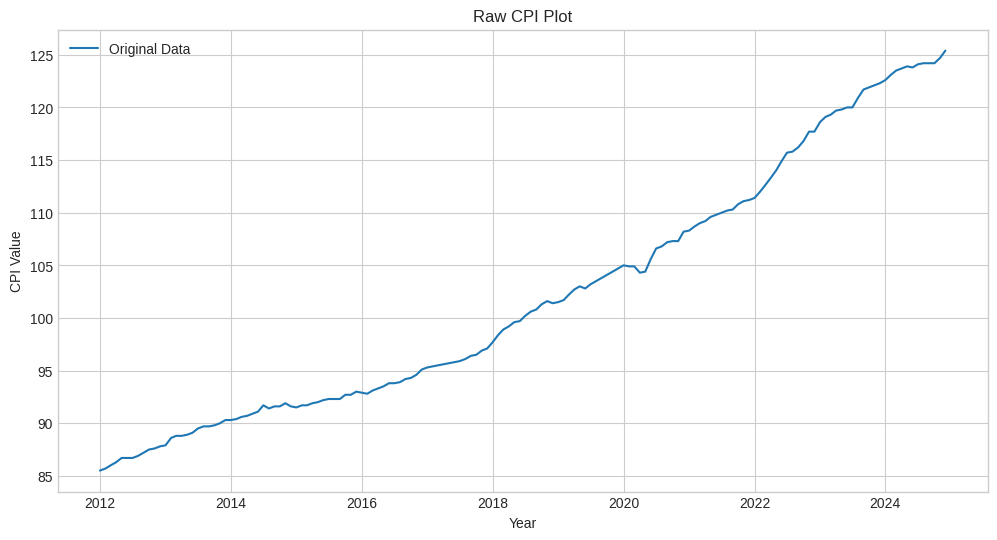

In [158]:
plt.figure(figsize=(12, 6))
plt.plot(df_copy.index, df_copy['Official Core Consumer Price Index'], label='Original Data')

plt.title('Raw CPI Plot')
plt.xlabel('Year')
plt.ylabel('CPI Value')

plt.legend()
plt.show()

**Observations**

*   The graph shows a consistent increase in CPI over the 13 years.
    *   From 2012 to 2020, the trend is linear, showing steady, predictable growth. Then, from 2021 to 2024, the trend becomes exponential or much steeper, which indicates that the cost of goods and services is rising at a significantly faster rate than in the previous decade.
    *   There’s also a small drop or pause around 2020 (likely due to the pandemic), followed by a quick recovery and faster growth.
*   Because of the upward trend, data transformations (like differencing or log transformation) will likely be performed to make the data stationary.




## Comparisson With other Countries

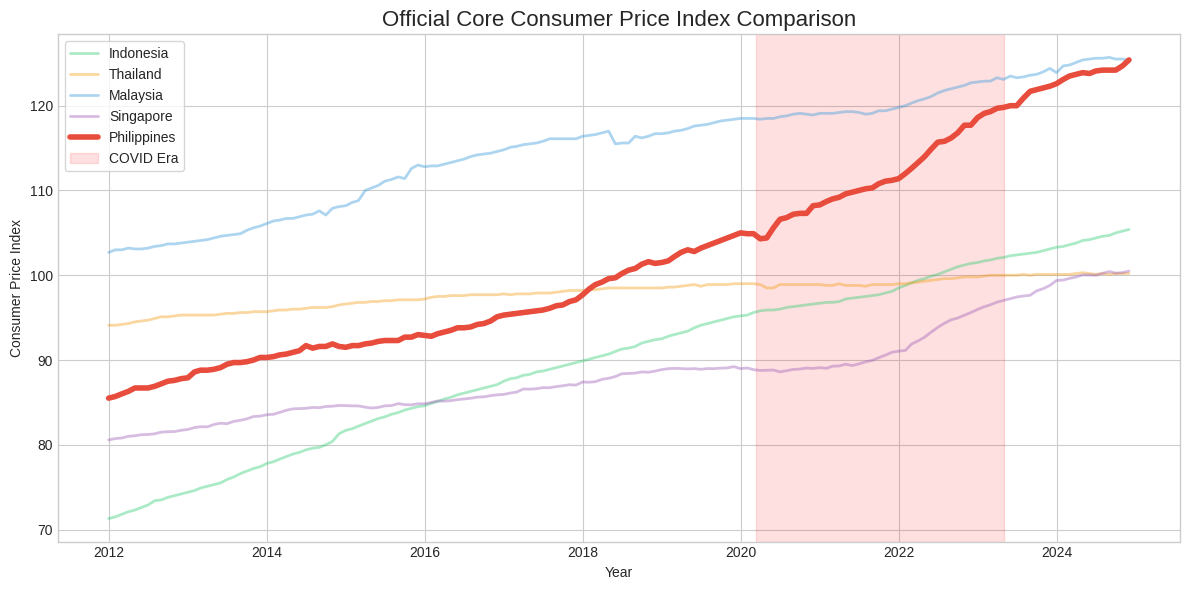

In [159]:
plt.figure(figsize=(12, 6))

# Plot other countries with lower emphasis
plt.plot(df_indo.index, df_indo.iloc[:, 0],
         label='Indonesia',
         color="#2ecc71",
         alpha=0.4,
         linewidth=2)

plt.plot(df_thai.index, df_thai.iloc[:, 0],
         label='Thailand',
         color="#f39c12",
         alpha=0.4,
         linewidth=2)

plt.plot(df_malay.index, df_malay.iloc[:, 0],
         label='Malaysia',
         color="#3498db",
         alpha=0.4,
         linewidth=2)

plt.plot(df_singapore.index, df_singapore.iloc[:, 0],
         label='Singapore',
         color="#9b59b6",
         alpha=0.4,
         linewidth=2)

# Philippines (df_copy) emphasized
plt.plot(df_copy.index, df_copy.iloc[:, 0],
         label='Philippines',
         color='#e74c3c',
         linewidth=4,
         alpha=1,
         zorder=10)

plt.axvspan(pd.Timestamp('2020-03-11'),
            pd.Timestamp('2023-05-05'),
            alpha=0.12,
            color='red',
            label='COVID Era')

# Formatting
plt.title('Official Core Consumer Price Index Comparison', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Consumer Price Index')
plt.legend(frameon=True)
plt.tight_layout()

plt.show()

* Malaysia has the highest cumulative CPI growth, rising from ~103 to ~126. This signals persistently elevated underlying inflation over the entire period, well before and after COVID.

* Philippines (bold red line) shows the steepest acceleration, particularly during and after COVID. Starting around 86 in 2012, it surged past 125 by 2025 — the sharpest post-pandemic inflation among the five countries.

* Indonesia started the lowest (~71 in 2012) but climbed steadily to ~105 by 2025, reflecting moderate but consistent inflation over 13 years.

* Thailand is the most stable, barely moving from ~94 to ~101 — suggesting very well-contained core inflation throughout the period.

* Singapore is unique: its CPI actually dipped slightly around 2015–2020 (reflecting deflation/disinflation), then rose sharply post-COVID to ~100, catching up with the others.


## Slope Computation
- Slope = Rate of CPI Change per Year
- Tells how fast prices are rising on average

In [160]:
pandemic_start = pd.Timestamp("2020-03-11")
pandemic_end = pd.Timestamp("2023-05-05")

In [161]:
def prepare(df, country_name):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df.index.name = "date"
    df = df.sort_index()
    df.columns = ["Official Core Consumer Price Index"]

    pre = df[df.index <  pandemic_start]
    covid = df[(df.index >= pandemic_start) & (df.index <= pandemic_end)]
    post = df[df.index >  pandemic_end]

    return {"name": country_name, "pre": pre, "covid": covid, "post": post}

In [162]:
countries = [
    prepare(df_indo, "Indonesia"),
    prepare(df_malay, "Malaysia"),
    prepare(df_thai, "Thailand"),
    prepare(df_singapore, "Singapore"),
    prepare(df_copy, "Philippines")
]

In [163]:
def slope(df_slice):
    if len(df_slice) < 2:
        return np.nan
    y = df_slice["Official Core Consumer Price Index"].values
    x = (df_slice.index - df_slice.index[0]).days / 365.25
    m, _ = np.polyfit(x, y, 1)    # m = CPI pts per year
    return round(m, 2)

In [164]:
records = []
for c in countries:
    records.append({
        "Country": c["name"],
        "Pre-COVID (pts/yr)":  slope(c["pre"]),
        "COVID Era (pts/yr)":  slope(c["covid"]),
        "Post-COVID (pts/yr)": slope(c["post"]),
    })

df_slopes = pd.DataFrame(records).set_index("Country")
print(df_slopes)

             Pre-COVID (pts/yr)  COVID Era (pts/yr)  Post-COVID (pts/yr)
Country                                                                 
Indonesia                  3.01                2.21                 2.13
Malaysia                   2.18                1.62                 1.78
Thailand                   0.58                0.43                 0.13
Singapore                  1.06                2.95                 2.31
Philippines                2.24                4.89                 3.18


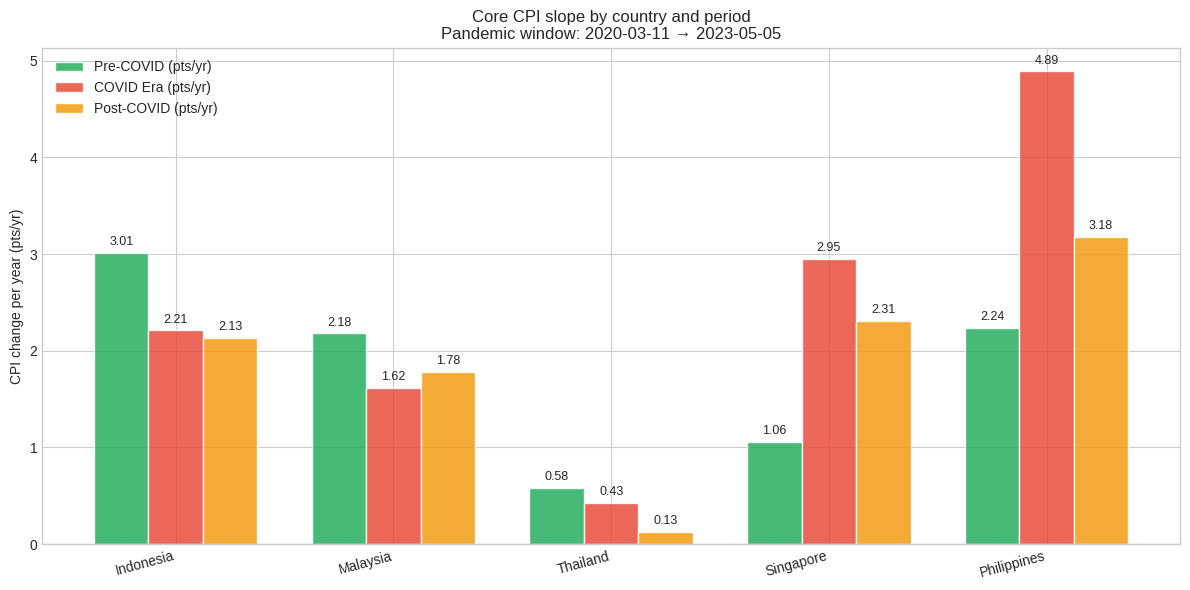

In [165]:
fig, ax = plt.subplots(figsize=(12, 6))

periods = df_slopes.columns.tolist()
x       = np.arange(len(df_slopes))
width   = 0.25
colors  = ["#27ae60", "#e74c3c", "#f39c12"]

for i, (period, color) in enumerate(zip(periods, colors)):
    bars = ax.bar(x + i * width, df_slopes[period],
                  width, label=period, color=color,
                  alpha=0.85, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.05, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(df_slopes.index, rotation=15, ha="right")
ax.set_ylabel("CPI change per year (pts/yr)")
ax.set_title(
    "Core CPI slope by country and period\n"
    f"Pandemic window: {pandemic_start.date()} → {pandemic_end.date()}"
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("cpi_slopes.png", dpi=150)
plt.show()

**Indonesia**

Pre-COVID slope was the highest of all countries at 3.01 pts/yr, but steadily slowed through COVID (2.21) and post-COVID (2.13). Inflation was already running hot before the pandemic and has been cooling since.

**Malaysia**

Relatively stable pre-COVID (2.18), dipped during COVID (1.62), then picked back up post-COVID (1.78). Suggests the pandemic briefly suppressed inflation but it's creeping back.

**Thailand**

The lowest slopes across all three periods (0.58 → 0.43 → 0.13). Post-COVID slope of just 0.13 pts/yr means prices are barely moving.

**Singapore**

Pre-COVID was modest at 1.06, then nearly tripled during COVID (2.95), and remains elevated post-COVID (2.31). A clear supply-shock driven inflation spike that hasn't fully unwound.

**Philippines**

Already moderate pre-COVID (2.24), then exploded to 4.89 pts/yr during COVID - by far the highest of any country in any period. Post-COVID it remains high at 3.18, the highest post-pandemic slope in the group.

## Decomposition

Multiplicative Decomposition


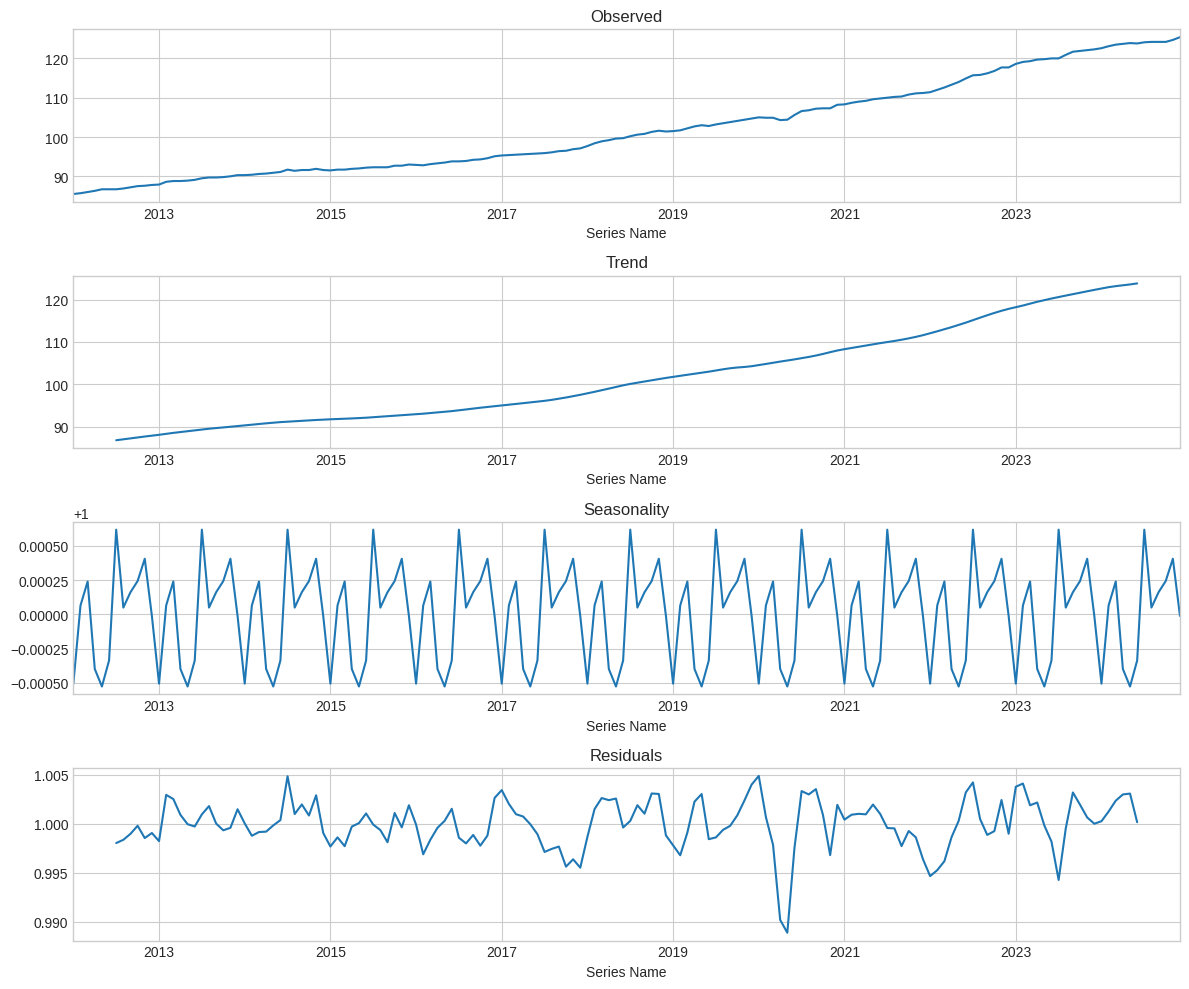

In [166]:
print("Multiplicative Decomposition")
decomposition = seasonal_decompose(df_copy['Official Core Consumer Price Index'], model='multiplicative', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=ax1, title='Observed')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonality')
decomposition.resid.plot(ax=ax4, title='Residuals')
plt.tight_layout()
plt.show()

**Observations**

* Observed
    * In the raw data, prices keep increasing from 2012 to 2024. Then, the increase becomes faster after 2021
* Trend
    * From 2012 to 2020, there was a steady and almost linear growth. But after 2021, there is an inflection point where the slope increases. In a multiplicative model, this indicates that the underlying growth rate (the percentage increase month-over-month) has accelerated.
* Seasonality
    * It shows a consistent repeating pattern every 12 months
    * The effect is very small (around ±0.05%), so it does not affect prices much compared to the trend
* Residuals
    * There is a significant downward spike around 2020. This shows an unusual event, likely the impact of the pandemic, where prices were about 1% lower than expected based on the trend.


## Testing Stationarity

In [167]:
result = adfuller(df_copy["Official Core Consumer Price Index"])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] > 0.05:
    print("Conclusion: Data is NON-STATIONARY (Has Trend/Seasonality)")
else:
    print("Conclusion: Data is STATIONARY")

ADF Statistic: 2.702990375798873
p-value: 0.9990871712173726
Conclusion: Data is NON-STATIONARY (Has Trend/Seasonality)


**Observation**

* It reveals that the data is non-stationary since the ADF test shows a positive ADF statistic (2.70) and a very high p-value (0.999). It needs transformations (like differencing or log transformation) before it can be used for accurate forecasting.

## Autocorrelation

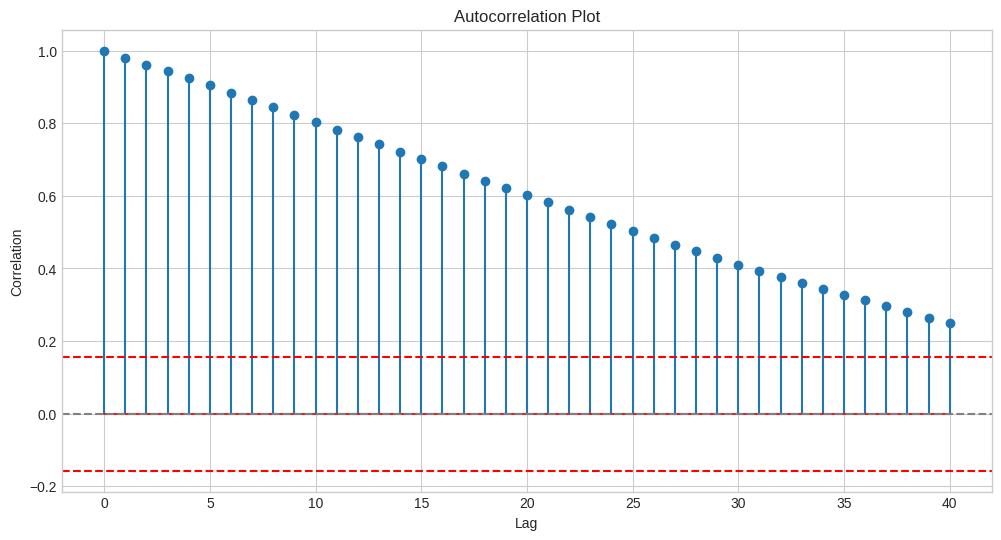

In [168]:
plt.figure(figsize=(12, 6))
acf_values = acf(df_copy['Official Core Consumer Price Index'], nlags=40)
plt.stem(range(len(acf_values)), acf_values)
plt.title('Autocorrelation Plot')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.axhline(y=0, linestyle='--', color='gray')
# Confidence interval lines
plt.axhline(y=-1.96/np.sqrt(len(df_copy)), linestyle='--', color='red')
plt.axhline(y=1.96/np.sqrt(len(df_copy)), linestyle='--', color='red')
plt.show()

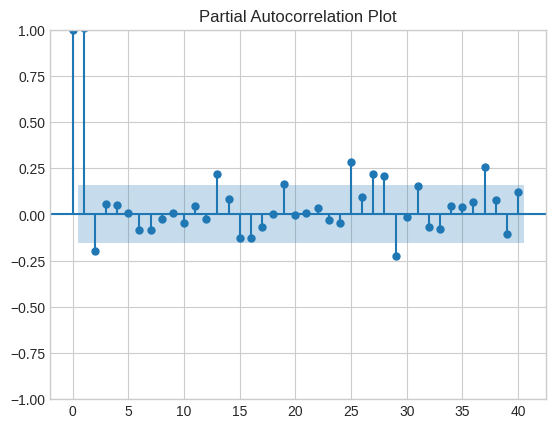

In [169]:
plot_pacf(df_copy['Official Core Consumer Price Index'],
          lags=40, method='ols', title="Partial Autocorrelation Plot")
plt.show()

**Observations**

* The series shows strong persistence, with correlations staying significant across many lags.

* The slow decay of autocorrelation suggests a trend‑like or autoregressive process rather than random noise.

* Because correlations remain significant at long lags, the series may be non‑stationary, requiring differencing before modeling.

# **Pre-processing**

### Making the data stationary

In [170]:
df_diff = df_copy.copy()
df_diff['Log_CPI'] = np.log(df_diff['Official Core Consumer Price Index'])

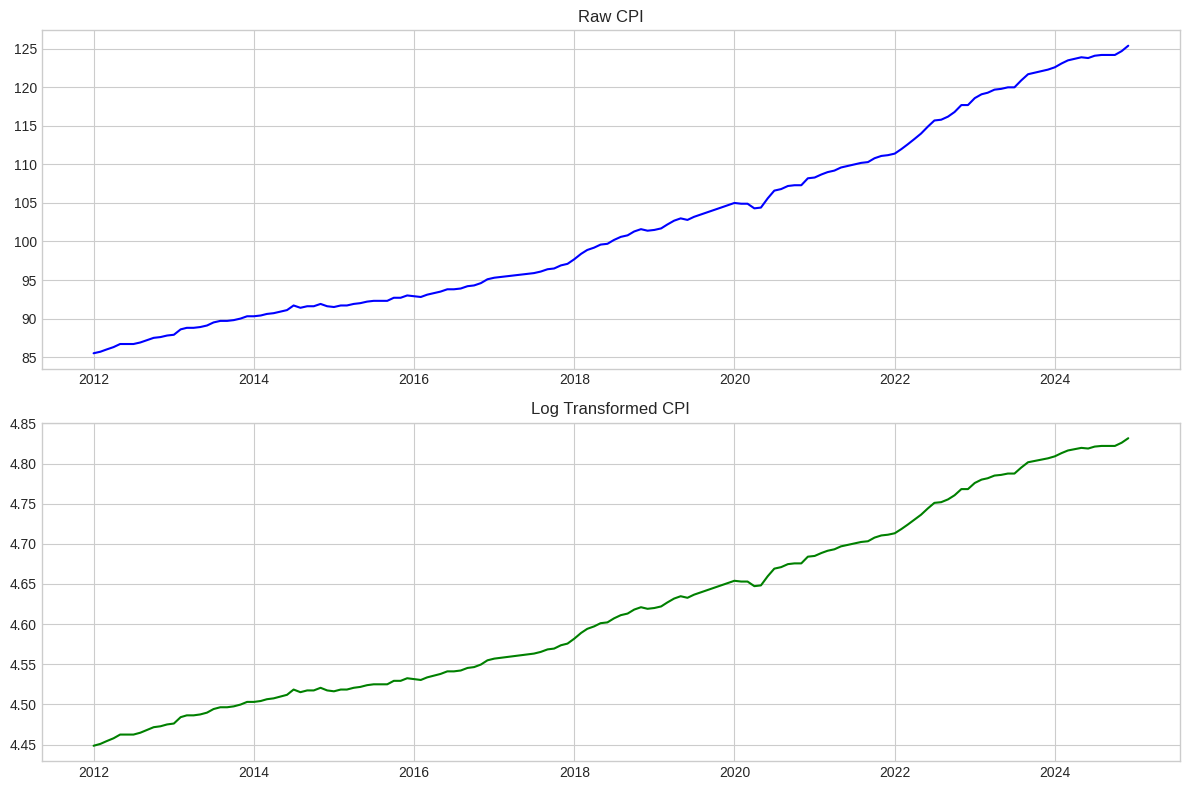

In [171]:
plt.figure(figsize=(12, 8))

plt.subplot(2,1,1)
plt.plot(df_diff.index,df_diff['Official Core Consumer Price Index'], color = 'blue')
plt.title('Raw CPI')

plt.subplot(2,1,2)
plt.plot(df_diff.index,df_diff['Log_CPI'],color = 'green'
)
plt.title('Log Transformed CPI')

plt.tight_layout()
plt.show()

In [172]:
result = adfuller(df_diff['Log_CPI'])
print('ADF Statistic after Log Transformation:', result[0])
print('p-value after Log Transformation:', result[1])
if result[1] > 0.05:
    print("Conclusion: Data is NON-STATIONARY (Has Trend/Seasonality)")
else:
    print("Conclusion: Data is STATIONARY")

ADF Statistic after Log Transformation: 1.770232060178194
p-value after Log Transformation: 0.9982881132758815
Conclusion: Data is NON-STATIONARY (Has Trend/Seasonality)


## Differencing

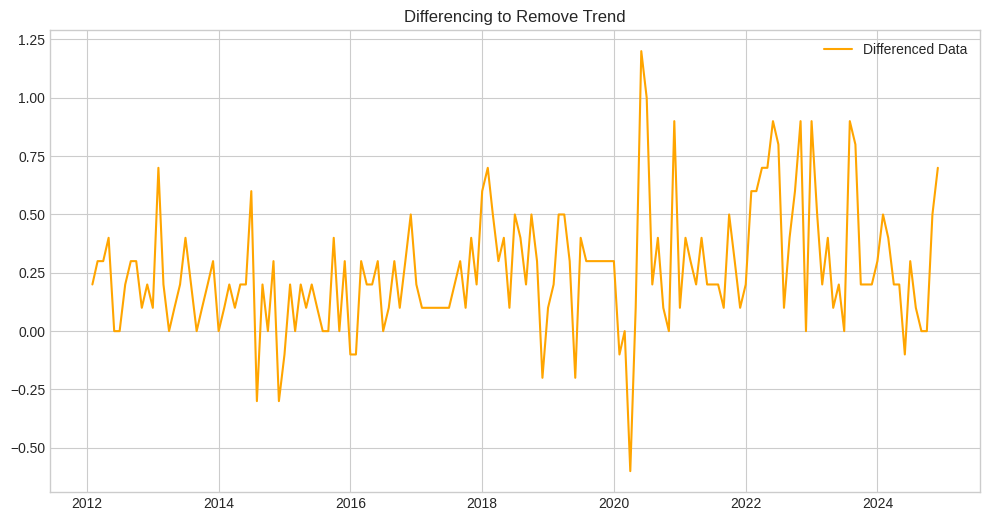

ADF Statistic after Differencing: -9.398037745998202
p-value after Differencing: 6.296445959524986e-16
Conclusion: Data is STATIONARY


In [173]:
df_diff['Diff_CPI'] = df_diff['Official Core Consumer Price Index'].diff()

df_diff = df_diff.dropna()

plt.figure(figsize=(12, 6))
plt.plot(df_diff.index, df_diff['Diff_CPI'], label='Differenced Data', color='orange')
plt.title('Differencing to Remove Trend')
plt.legend()
plt.show()

# Verify Stationarity after Differencing
result = adfuller(df_diff['Diff_CPI'])
print('ADF Statistic after Differencing:', result[0])
print('p-value after Differencing:', result[1])
if result[1] > 0.05:
    print("Conclusion: Data is NON-STATIONARY (Has Trend/Seasonality)")
else:
    print("Conclusion: Data is STATIONARY")

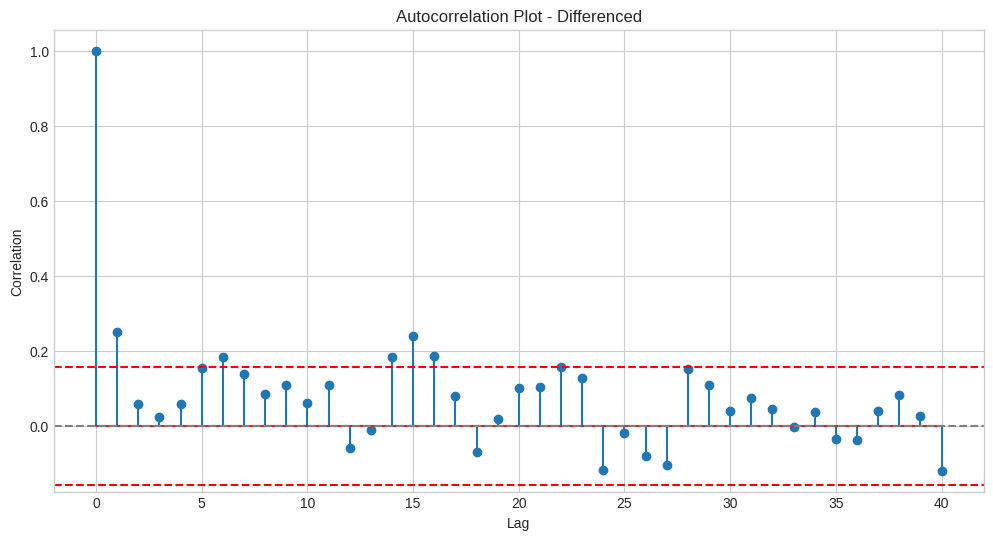

In [174]:
plt.figure(figsize=(12, 6))
acf_values = acf(df_diff['Diff_CPI'], nlags=40)
plt.stem(range(len(acf_values)), acf_values)
plt.title('Autocorrelation Plot - Differenced')
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.axhline(y=0, linestyle='--', color='gray')
# Confidence interval lines
plt.axhline(y=-1.96/np.sqrt(len(df_copy)), linestyle='--', color='red')
plt.axhline(y=1.96/np.sqrt(len(df_copy)), linestyle='--', color='red')
plt.show()

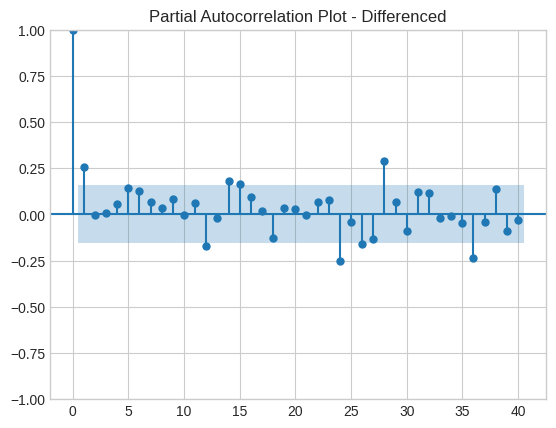

In [175]:
plot_pacf(df_diff['Diff_CPI'], lags=40, method='ols')
plt.title('Partial Autocorrelation Plot - Differenced')
plt.show()

**Observations**
* The ADF statistic of -9.39 is strongly negative, reinforcing rejection of the null hypothesis of non‑stationarity.

* The p‑value (~6.3e‑16) is far below 0.05, confirming the differenced CPI series is statistically stationary.

* With stationarity achieved, the data is now appropriate for ARIMA or similar time‑series models, enabling reliable forecasting of inflation dynamics.

# **Modeling**

## Moving Average

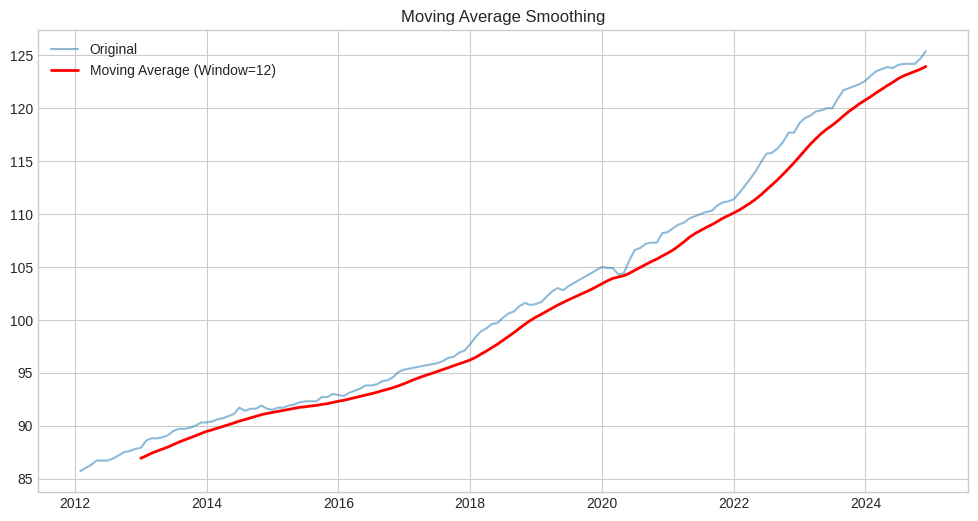

In [176]:
window_size = 12
df_diff["MA_Smooth"] = df_diff["Official Core Consumer Price Index"].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_diff.index, df_diff['Official Core Consumer Price Index'], label='Original', alpha=0.5)
plt.plot(df_diff.index, df_diff['MA_Smooth'], label=f'Moving Average (Window={window_size})', color='red', linewidth=2)
plt.title('Moving Average Smoothing')
plt.legend()
plt.show()

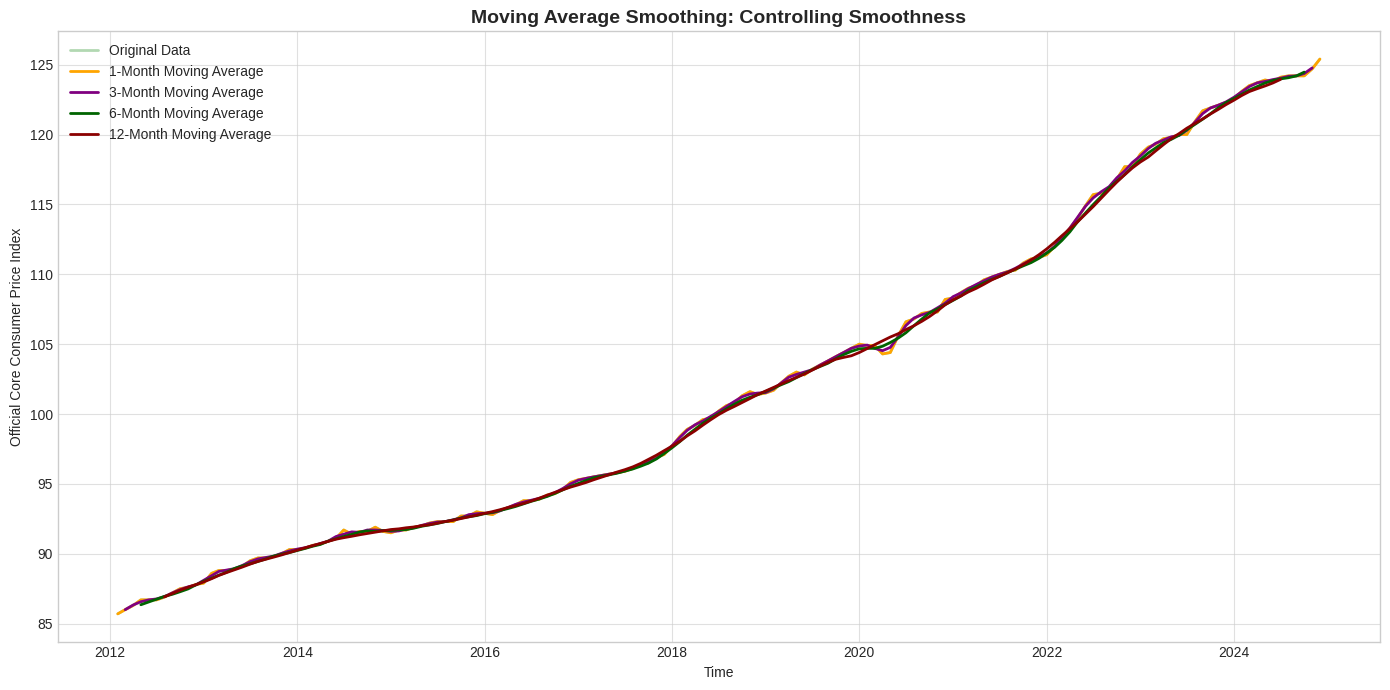


Effect of Window Size on Latest Smoothed Value:
 1-month MA: 125.40 CPI
 3-month MA: 124.77 CPI
 6-month MA: 124.47 CPI
 12-month MA: 123.95 CPI


In [177]:
# Compute rolling moving averages with different windows
windows = [1,3, 6, 12]  # 3-mo, 6-mo, annual
df_ma = df_diff.copy()

plt.figure(figsize=(14, 7))
plt.plot(df_diff.index, df_diff['Official Core Consumer Price Index'], label='Original Data', color='green', linewidth=2, alpha=0.3)

colors = ['orange', 'purple', 'darkgreen',"darkred"]
for window, color in zip(windows, colors):
    col_name = f'MA_{window}'
    df_ma[col_name] = df_ma['Official Core Consumer Price Index'].rolling(window=window, center=True).mean()
    plt.plot(df_ma.index, df_ma[col_name], label=f'{window}-Month Moving Average',
             color=color, linewidth=2)

plt.title('Moving Average Smoothing: Controlling Smoothness', fontsize=14, fontweight='bold')
plt.xlabel('Time'); plt.ylabel('Official Core Consumer Price Index')
plt.legend(); plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()

print("\nEffect of Window Size on Latest Smoothed Value:")
for window in windows:
    col_name = f'MA_{window}'

    # 1. Drop the NaNs caused by centering
    # 2. Take the last available real number
    latest_val = df_ma[col_name].dropna().iloc[-1]

    print(f" {window}-month MA: {latest_val:.2f} CPI")

## Train-test Split

In [178]:
# Last 72 months (6 years) held out as test set
train = df_diff.iloc[:-72]
test = df_diff.iloc[-72:]

In [179]:
def evaluate_stat_model(actual_log, predicted_log, model_name, avg_cpi_level=110):

    # Log-space metrics
    rmse_log = np.sqrt(mean_squared_error(actual_log, predicted_log))
    mae_log = mean_absolute_error(actual_log, predicted_log)
    mape_log = np.mean(np.abs((actual_log - predicted_log) / np.abs(actual_log))) * 100

    # Back-transform to original scale
    actual_cpi = np.exp(actual_log)
    predicted_cpi = np.exp(predicted_log)
    rmse_cpi = np.sqrt(mean_squared_error(actual_cpi, predicted_cpi))
    mae_cpi = mean_absolute_error(actual_cpi, predicted_cpi)
    mape_cpi = np.mean(np.abs((actual_cpi - predicted_cpi) / actual_cpi)) * 100

    print(f"\n{'═'*62}")
    print(f" {model_name}")
    print(f"{'═'*62}")
    print(f" {'Metric':<32} {'Log-Scale':>12} {'CPI Scale':>12}")
    print(f" {'─'*56}")
    print(f" {'RMSE':<32} {rmse_log:>12.4f} {rmse_cpi:>12.4f}")
    print(f" {'MAE':<32} {mae_log:>12.4f} {mae_cpi:>12.4f}")
    print(f" {'MAPE (%)':<32} {mape_log:>12.2f} {mape_cpi:>12.2f}")
    print(f"{'─'*62}")

    print(f" Plain English: predictions are off by ±{mae_cpi:.2f} CPI index points on average.")
    print(f" (On a scale of ~84–125, ±{mae_cpi:.2f} pts ≈ {mae_cpi/avg_cpi_level*100:.2f}% of the typical CPI level)")

    return dict(model=model_name,
                rmse_log=rmse_log, mae_log=mae_log, mape_log=mape_log,
                rmse_cpi=rmse_cpi, mae_cpi=mae_cpi, mape_cpi=mape_cpi,
                actual_cpi=actual_cpi, predicted_cpi=predicted_cpi)

def evaluate_dl_model(actual_cpi, predicted_cpi, model_name):
    rmse = np.sqrt(mean_squared_error(actual_cpi, predicted_cpi))
    mae  = mean_absolute_error(actual_cpi, predicted_cpi)
    mape = np.mean(np.abs((actual_cpi - predicted_cpi) / actual_cpi)) * 100

    print(f"\n{'═'*55}")
    print(f"  {model_name}")
    print(f"{'═'*55}")
    print(f"  RMSE (CPI pts) : {rmse:.4f}")
    print(f"  MAE  (CPI pts) : {mae:.4f}")
    print(f"  MAPE (%) : {mape:.2f}%")

    return dict(model=model_name, rmse_cpi=rmse, mae_cpi=mae, mape_cpi=mape,
                actual_cpi=actual_cpi, predicted_cpi=predicted_cpi)

all_results = []

## ARIMA Model 1

In [180]:
# ARIMA (1,1,1)
arima1 = ARIMA(train['Log_CPI'], order=(1,1,1)).fit()
arima1_fc = arima1.get_forecast(steps=72)
arima1_ci = arima1_fc.conf_int()

res_arima1 = evaluate_stat_model(
    test['Log_CPI'].values,
    arima1_fc.predicted_mean.values,
    'ARIMA (1,1,1)'
)
all_results.append(res_arima1)



══════════════════════════════════════════════════════════════
 ARIMA (1,1,1)
══════════════════════════════════════════════════════════════
 Metric                              Log-Scale    CPI Scale
 ────────────────────────────────────────────────────────
 RMSE                                   0.1000      11.2597
 MAE                                    0.0808       9.0064
 MAPE (%)                                 1.69         7.61
──────────────────────────────────────────────────────────────
 Plain English: predictions are off by ±9.01 CPI index points on average.
 (On a scale of ~84–125, ±9.01 pts ≈ 8.19% of the typical CPI level)


## ARIMA Model 2

In [181]:
# ── ARIMA (2,1,1) ─────────────────────────────────────────────────────────────
arima2 = ARIMA(train['Log_CPI'], order=(2,1,1)).fit()
arima2_fc = arima2.get_forecast(steps=72)
arima2_ci = arima2_fc.conf_int()

res_arima2 = evaluate_stat_model(
    test['Log_CPI'].values,
    arima2_fc.predicted_mean.values,
    'ARIMA (2,1,1)'
)
all_results.append(res_arima2)



══════════════════════════════════════════════════════════════
 ARIMA (2,1,1)
══════════════════════════════════════════════════════════════
 Metric                              Log-Scale    CPI Scale
 ────────────────────────────────────────────────────────
 RMSE                                   0.1115      12.4462
 MAE                                    0.0917      10.1323
 MAPE (%)                                 1.92         8.58
──────────────────────────────────────────────────────────────
 Plain English: predictions are off by ±10.13 CPI index points on average.
 (On a scale of ~84–125, ±10.13 pts ≈ 9.21% of the typical CPI level)


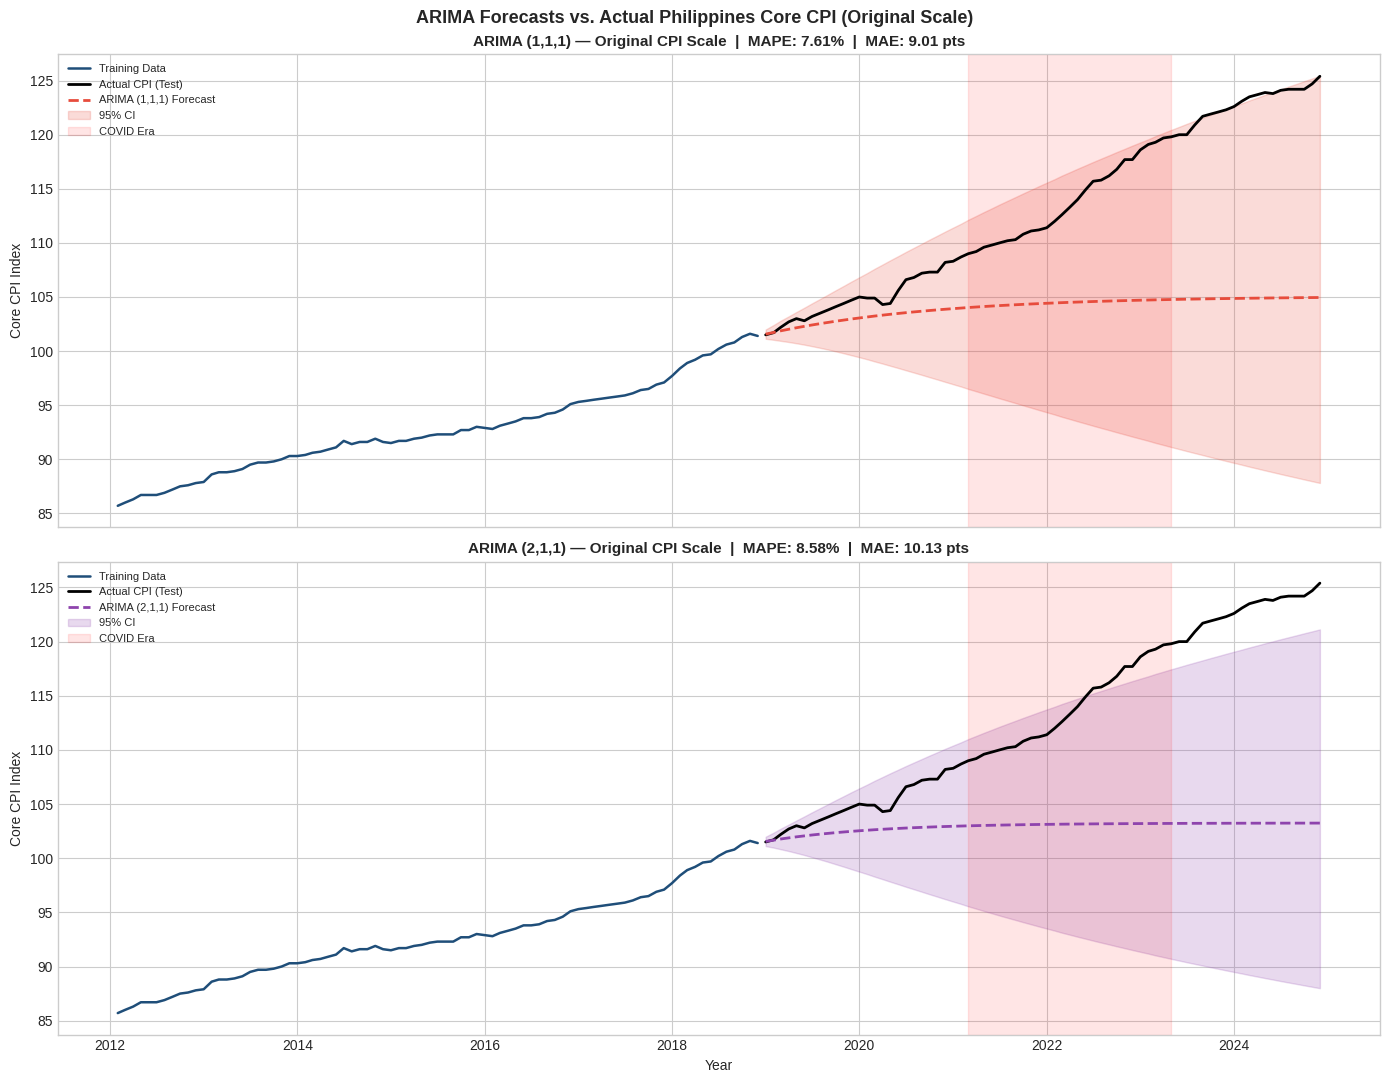

In [182]:
# Plot: ORIGINAL CPI SCALE
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

train_cpi = np.exp(train['Log_CPI'])
test_cpi  = np.exp(test['Log_CPI'])

for ax, res, fc, ci, color, name in [
    (axes[0], res_arima1, arima1_fc, arima1_ci, COLORS['accent'],  'ARIMA (1,1,1)'),
    (axes[1], res_arima2, arima2_fc, arima2_ci, COLORS['purple'],  'ARIMA (2,1,1)'),
]:
    pred_cpi = np.exp(fc.predicted_mean)
    ci_lo    = np.exp(ci.iloc[:, 0])
    ci_hi    = np.exp(ci.iloc[:, 1])

    ax.plot(train.index, train_cpi, color=COLORS['primary'], lw=1.8, label='Training Data')
    ax.plot(test.index,  test_cpi,  color='black', lw=2, label='Actual CPI (Test)')
    ax.plot(test.index,  pred_cpi,  color=color, lw=2, ls='--', label=f'{name} Forecast')
    ax.fill_between(test.index, ci_lo, ci_hi, alpha=0.2, color=color, label='95% CI')
    ax.axvspan(pd.Timestamp('2021-03'), pd.Timestamp('2023-05'),
               alpha=0.1, color='red', label='COVID Era')

    ax.set_title(f'{name} — Original CPI Scale  |  '
                 f'MAPE: {res["mape_cpi"]:.2f}%  |  MAE: {res["mae_cpi"]:.2f} pts',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Core CPI Index'); ax.legend(fontsize=8)

axes[1].set_xlabel('Year')
plt.suptitle('ARIMA Forecasts vs. Actual Philippines Core CPI (Original Scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## SARIMAX Model 1

In [183]:
# SARIMA (1,1,1)(1,1,1,12)
sarima1 = SARIMAX(train['Log_CPI'], order=(1,1,1),
                  seasonal_order=(1,1,1,12)).fit(disp=False)
sarima1_fc = sarima1.get_forecast(steps=72)
sarima1_ci = sarima1_fc.conf_int()

print(sarima1.summary())

res_sarima1 = evaluate_stat_model(
    test['Log_CPI'].values,
    sarima1_fc.predicted_mean.values,
    'SARIMA (1,1,1)(1,1,1,12)'
)
all_results.append(res_sarima1)


                                     SARIMAX Results                                      
Dep. Variable:                            Log_CPI   No. Observations:                   83
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 312.649
Date:                            Thu, 11 Jun 2026   AIC                           -615.298
Time:                                    06:37:57   BIC                           -604.056
Sample:                                02-01-2012   HQIC                          -610.832
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8950      0.307     -2.915      0.004      -1.497      -0.293
ma.L1          0.8146      0.374   

## SARIMAX Model 2

In [184]:
# ── SARIMA (2,1,1)(1,1,1,12) ──────────────────────────────────────────────────
sarima2 = SARIMAX(train['Log_CPI'], order=(2,1,1),
                  seasonal_order=(1,1,1,12)).fit(disp=False)
sarima2_fc = sarima2.get_forecast(steps=72)
sarima2_ci = sarima2_fc.conf_int()

print(sarima2.summary())

res_sarima2 = evaluate_stat_model(
    test['Log_CPI'].values,
    sarima2_fc.predicted_mean.values,
    'SARIMA (2,1,1)(1,1,1,12)'
)
all_results.append(res_sarima2)


                                     SARIMAX Results                                      
Dep. Variable:                            Log_CPI   No. Observations:                   83
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 312.941
Date:                            Thu, 11 Jun 2026   AIC                           -613.883
Time:                                    06:37:59   BIC                           -600.392
Sample:                                02-01-2012   HQIC                          -608.524
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7886      0.791     -0.997      0.319      -2.339       0.762
ar.L2          0.0149      0.205   

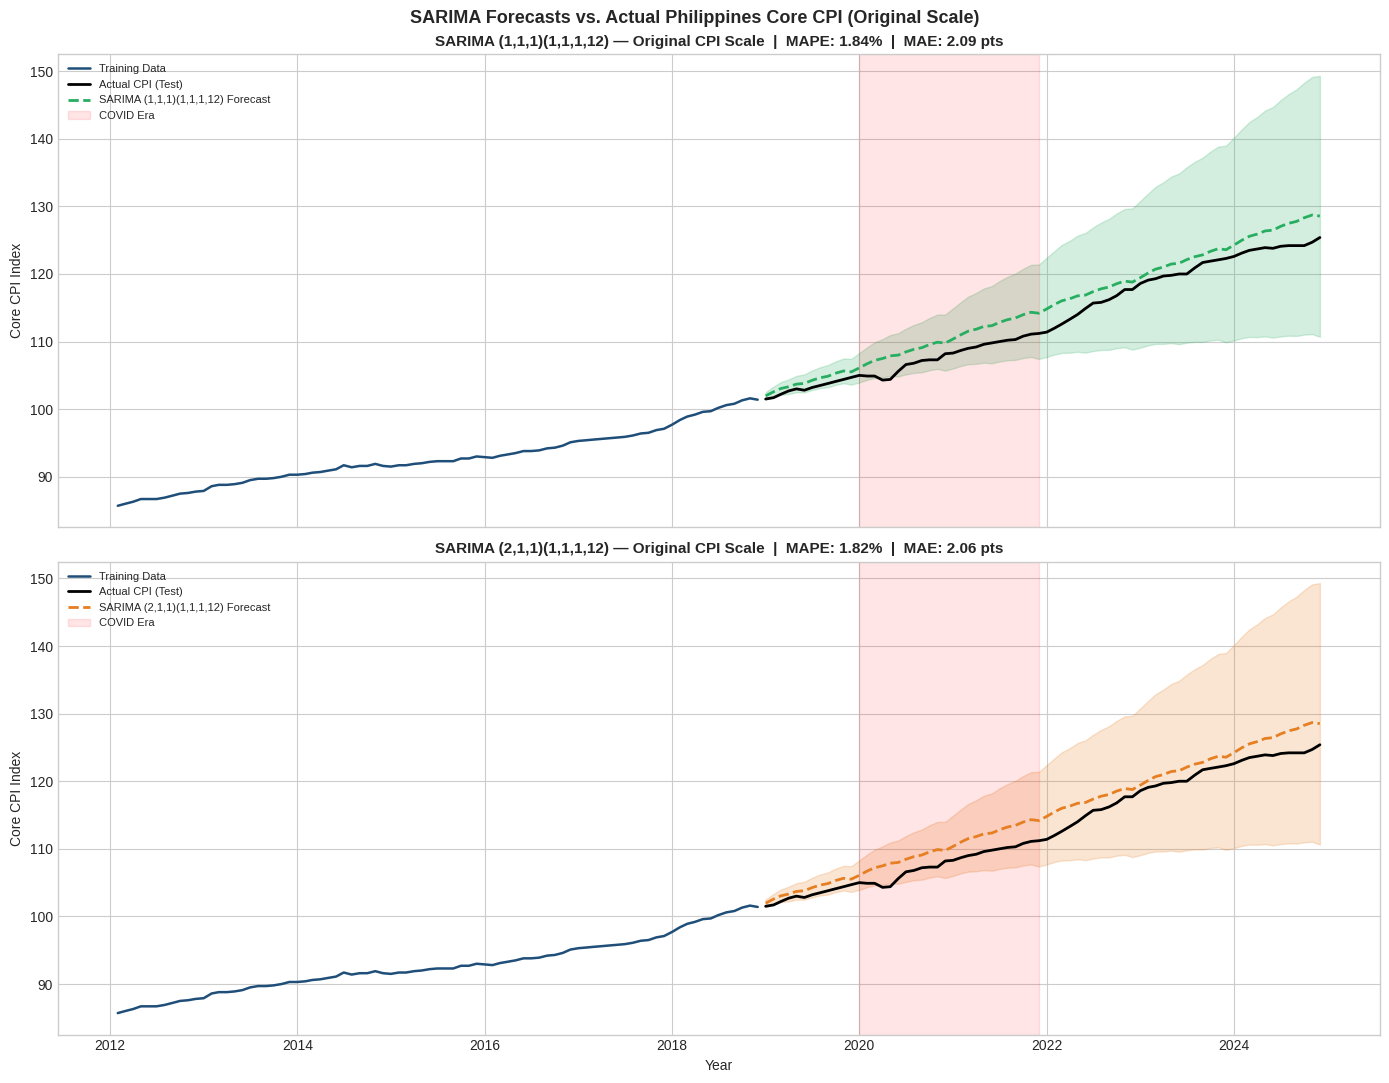

In [185]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

for ax, res, fc, ci, color, name in [
    (axes[0], res_sarima1, sarima1_fc, sarima1_ci, COLORS['green'],  'SARIMA (1,1,1)(1,1,1,12)'),
    (axes[1], res_sarima2, sarima2_fc, sarima2_ci, COLORS['orange'], 'SARIMA (2,1,1)(1,1,1,12)'),
]:
    pred_cpi = np.exp(fc.predicted_mean)
    ci_lo    = np.exp(ci.iloc[:, 0])
    ci_hi    = np.exp(ci.iloc[:, 1])

    ax.plot(train.index, np.exp(train['Log_CPI']), color=COLORS['primary'], lw=1.8, label='Training Data')
    ax.plot(test.index,  np.exp(test['Log_CPI']),  color='black', lw=2, label='Actual CPI (Test)')
    ax.plot(test.index,  pred_cpi, color=color, lw=2, ls='--', label=f'{name} Forecast')
    ax.fill_between(test.index, ci_lo, ci_hi, alpha=0.2, color=color)
    ax.axvspan(pd.Timestamp('2020-01'), pd.Timestamp('2021-12'),
               alpha=0.1, color='red', label='COVID Era')
    ax.set_title(f'{name} — Original CPI Scale  |  '
                 f'MAPE: {res["mape_cpi"]:.2f}%  |  MAE: {res["mae_cpi"]:.2f} pts',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Core CPI Index'); ax.legend(fontsize=8)

axes[1].set_xlabel('Year')
plt.suptitle('SARIMA Forecasts vs. Actual Philippines Core CPI (Original Scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# Modeling - Deep Learning

In [186]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_copy[CPI_COL].values.reshape(-1, 1))

LOOKBACK = 12

def make_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, LOOKBACK)

X_train, X_test = X[:-72], X[-72:]
y_train, y_test = y[:-72], y[-72:]

X_tr3 = X_train.reshape(*X_train.shape, 1)
X_te3 = X_test.reshape(*X_test.shape, 1)

y_test_cpi = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
test_dates  = df_copy.index[-72:]

print(f"DL Training sequences: {X_train.shape}  Test sequences: {X_test.shape}")
print(f"Test period: {test_dates[0]:%b %Y} → {test_dates[-1]:%b %Y}")

DL Training sequences: (72, 12)  Test sequences: (72, 12)
Test period: Jan 2019 → Dec 2024


## RNN

In [187]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

rnn_model = Sequential([
    SimpleRNN(50, input_shape=(LOOKBACK, 1), return_sequences=False),
    Dense(1)
])
rnn_model.compile(optimizer=Adam(0.001), loss='mse')
print("Training Simple RNN...")
rnn_model.fit(X_tr3, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)

rnn_pred_cpi = scaler.inverse_transform(rnn_model.predict(X_te3)).flatten()

res_rnn = evaluate_dl_model(y_test_cpi, rnn_pred_cpi, 'Simple RNN')
all_results.append(res_rnn)

Training Simple RNN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

═══════════════════════════════════════════════════════
  Simple RNN
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 10.8785
  MAE  (CPI pts) : 9.7753
  MAPE (%) : 8.41%


## LSTM

In [188]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

lstm_model = Sequential([
    LSTM(50, input_shape=(LOOKBACK, 1), return_sequences=False),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(0.001), loss='mse')
print("Training LSTM...")
lstm_model.fit(X_tr3, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)

lstm_pred_cpi = scaler.inverse_transform(lstm_model.predict(X_te3)).flatten()

res_lstm = evaluate_dl_model(y_test_cpi, lstm_pred_cpi, 'LSTM')
all_results.append(res_lstm)

Training LSTM...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step

═══════════════════════════════════════════════════════
  LSTM
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 6.3474
  MAE  (CPI pts) : 5.7527
  MAPE (%) : 4.95%


## Transformer

In [189]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.ln1 = LayerNormalization(epsilon=1e-6)
        self.ln2 = LayerNormalization(epsilon=1e-6)
        self.d1  = Dropout(rate); self.d2 = Dropout(rate)
    def call(self, x, training=False):
        a = self.att(x, x)
        a = self.d1(a, training=training)
        x = self.ln1(x + a)
        f = self.d2(self.ffn(x), training=training)
        return self.ln2(x + f)

def build_transformer():
    inputs = Input(shape=(LOOKBACK, 1))
    x = Dense(64)(inputs)
    x = TransformerBlock(64, 4, 64)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)
    x = Dense(25, activation='relu')(x)
    outputs = Dense(1)(x)
    m = tf.keras.Model(inputs, outputs)
    m.compile(optimizer=Adam(0.001), loss='mse')
    return m

tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)
trans_model = build_transformer()
print("Training Transformer...")
trans_model.fit(X_tr3, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)

trans_pred_cpi = scaler.inverse_transform(trans_model.predict(X_te3)).flatten()

res_trans = evaluate_dl_model(y_test_cpi, trans_pred_cpi, 'Transformer')
all_results.append(res_trans)


Training Transformer...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step

═══════════════════════════════════════════════════════
  Transformer
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 24.0246
  MAE  (CPI pts) : 23.1491
  MAPE (%) : 20.19%


## CNN

In [190]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(LOOKBACK, 1)),
    Conv1D(64, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer=Adam(0.001), loss='mse')
print("Training 1D CNN...")
cnn_model.fit(X_tr3, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)

cnn_pred_cpi = scaler.inverse_transform(cnn_model.predict(X_te3)).flatten()

res_cnn = evaluate_dl_model(y_test_cpi, cnn_pred_cpi, '1D CNN')
all_results.append(res_cnn)


Training 1D CNN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

═══════════════════════════════════════════════════════
  1D CNN
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 6.6779
  MAE  (CPI pts) : 6.0935
  MAPE (%) : 5.25%


## Graphs

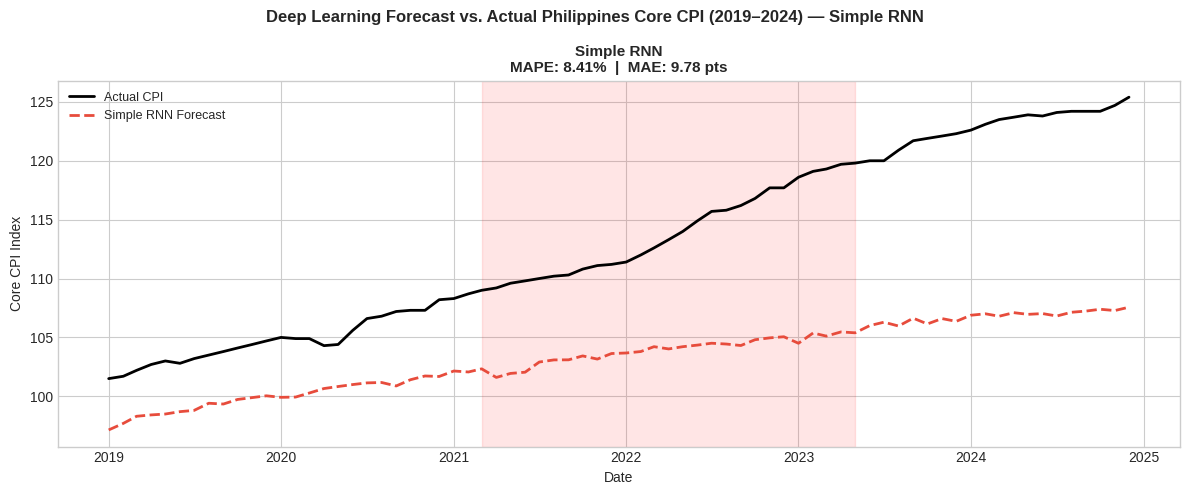

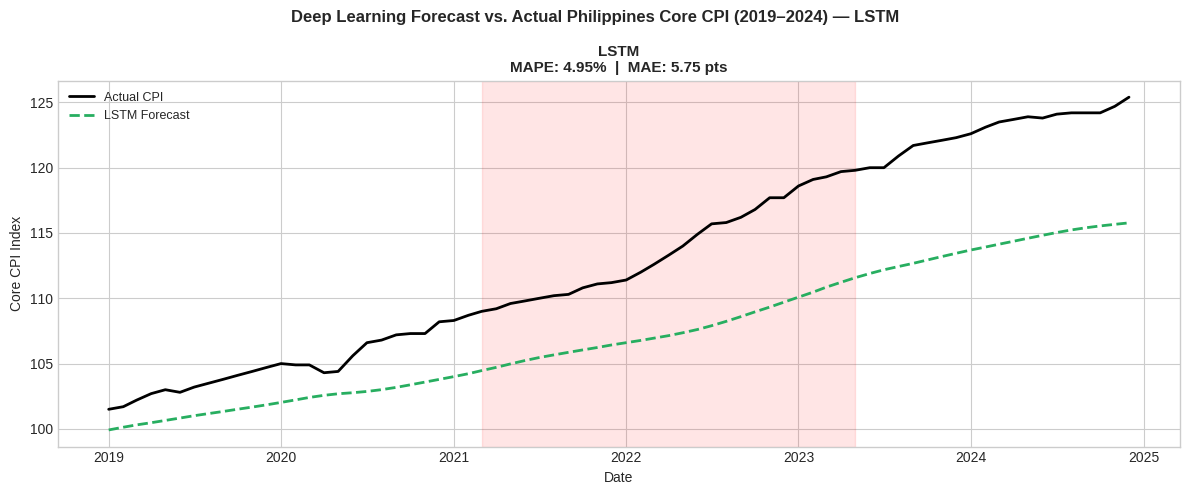

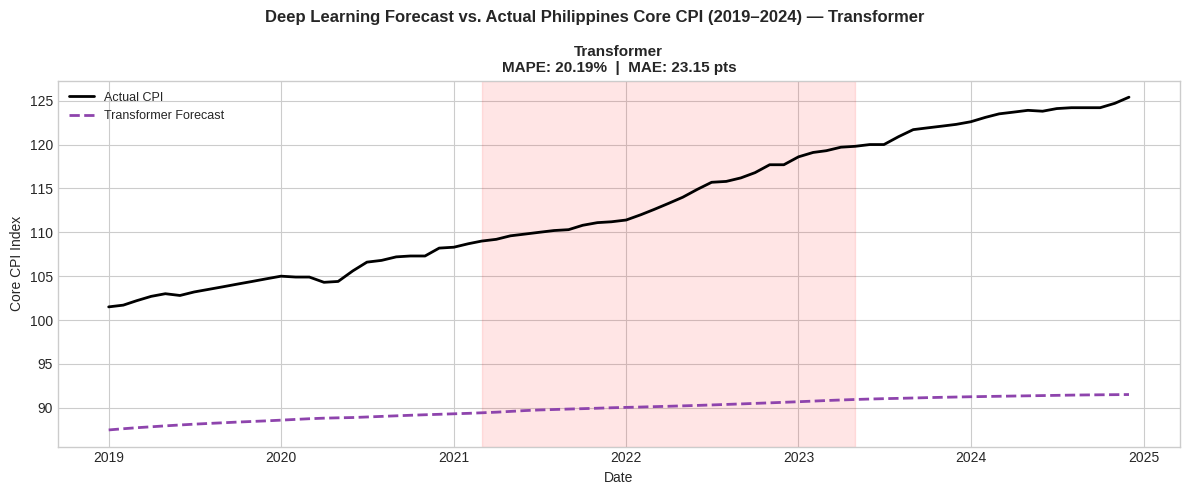

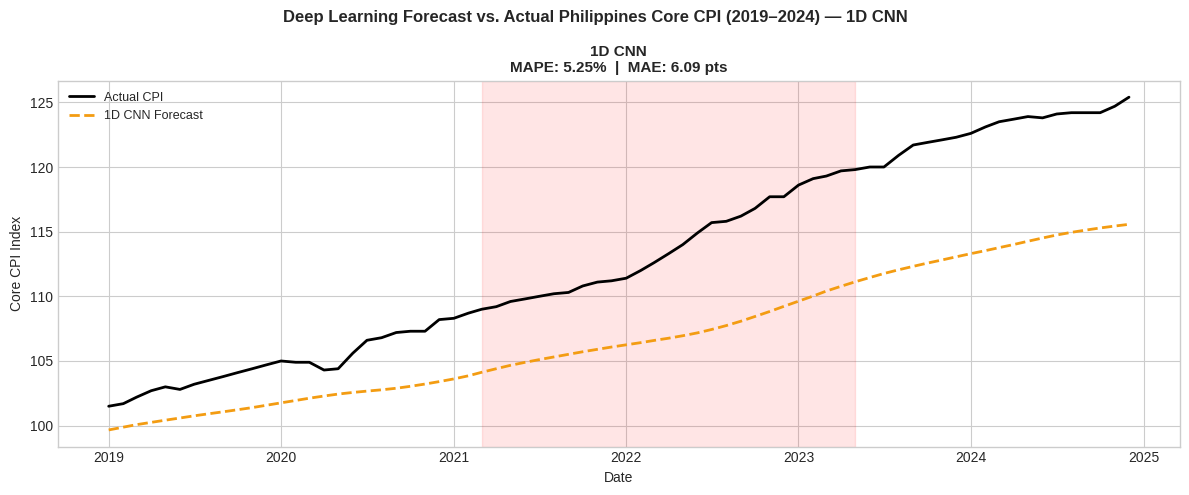

In [191]:
dl_items = [
    (res_rnn,   rnn_pred_cpi,   COLORS['accent'],  'Simple RNN'),
    (res_lstm,  lstm_pred_cpi,  COLORS['green'],   'LSTM'),
    (res_trans, trans_pred_cpi, COLORS['purple'],  'Transformer'),
    (res_cnn,   cnn_pred_cpi,   COLORS['gold'],    '1D CNN'),
]

for res, pred, color, name in dl_items:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(test_dates, y_test_cpi,
            color='black', lw=2, label='Actual CPI')
    ax.plot(test_dates, pred,
            color=color, lw=2, ls='--', label=f'{name} Forecast')
    ax.axvspan(pd.Timestamp('2021-03'), pd.Timestamp('2023-05'),
               alpha=0.1, color='red')

    ax.set_title(
        f'{name}\nMAPE: {res["mape_cpi"]:.2f}%  |  MAE: {res["mae_cpi"]:.2f} pts',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Date')
    ax.set_ylabel('Core CPI Index')
    ax.legend(fontsize=9)

    plt.suptitle(
        f'Deep Learning Forecast vs. Actual Philippines Core CPI (2019–2024) — {name}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'cpi_forecast_{name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

**Observations**

* **Simple RNN:** Tends to underfit long sequences due to the vanishing gradient problem. May track the general upward trend but lag behind sharp changes like the post-COVID surge.

* **LSTM:** Designed to overcome RNN's vanishing gradient via memory gates. Expected to better capture medium-term dependencies (e.g., the sustained post-2021 inflation) compared to Simple RNN.

* **Transformer:** Leverages multi-head self-attention to relate all time steps simultaneously. With only 12-step lookback and limited data, attention may not offer a decisive advantage over LSTM here, but its MAPE will indicate whether global patterns outperform local ones.

* **1D CNN:** Extracts local temporal features via convolutional filters. Works well for pattern detection in short windows; may miss long-range trends but can be surprisingly competitive on CPI data where month-to-month patterns are consistent.


## In-Sample / Out-sample Testing

In [192]:
all_in_sample_results = []

SKIP_ARIMA  = 1     # ARIMA(p,1,q):     d = 1
SKIP_SARIMA = 13    # SARIMA(p,1,q)(P,1,Q,12): d + D*s = 1 + 12

N_train = len(train)

# ARIMA (1,1,1)
arima1_in    = arima1.get_prediction(start=SKIP_ARIMA, end=N_train - 1, dynamic=SKIP_ARIMA)
arima1_in_ci = arima1_in.conf_int()

res_arima1_in = evaluate_stat_model(
    train['Log_CPI'].iloc[SKIP_ARIMA:].values,
    arima1_in.predicted_mean.values,
    'ARIMA (1,1,1) [In-Sample]'
)
all_in_sample_results.append(res_arima1_in)


## ARIMA Model 2 — In-Sample

# ARIMA (2,1,1)
arima2_in    = arima2.get_prediction(start=SKIP_ARIMA, end=N_train - 1, dynamic=SKIP_ARIMA)
arima2_in_ci = arima2_in.conf_int()

res_arima2_in = evaluate_stat_model(
    train['Log_CPI'].iloc[SKIP_ARIMA:].values,
    arima2_in.predicted_mean.values,
    'ARIMA (2,1,1) [In-Sample]'
)
all_in_sample_results.append(res_arima2_in)


#  SARIMA (1,1,1)(1,1,1,12)
sarima1_in    = sarima1.get_prediction(start=SKIP_SARIMA, end=N_train - 1, dynamic=SKIP_SARIMA)
sarima1_in_ci = sarima1_in.conf_int()

res_sarima1_in = evaluate_stat_model(
    train['Log_CPI'].iloc[SKIP_SARIMA:].values,
    sarima1_in.predicted_mean.values,
    'SARIMA (1,1,1)(1,1,1,12) [In-Sample]'
)
all_in_sample_results.append(res_sarima1_in)


# SARIMA (2,1,1)(1,1,1,12)
sarima2_in    = sarima2.get_prediction(start=SKIP_SARIMA, end=N_train - 1, dynamic=SKIP_SARIMA)
sarima2_in_ci = sarima2_in.conf_int()

res_sarima2_in = evaluate_stat_model(
    train['Log_CPI'].iloc[SKIP_SARIMA:].values,
    sarima2_in.predicted_mean.values,
    'SARIMA (2,1,1)(1,1,1,12) [In-Sample]'
)
all_in_sample_results.append(res_sarima2_in)


══════════════════════════════════════════════════════════════
 ARIMA (1,1,1) [In-Sample]
══════════════════════════════════════════════════════════════
 Metric                              Log-Scale    CPI Scale
 ────────────────────────────────────────────────────────
 RMSE                                   0.0574       5.3597
 MAE                                    0.0462       4.2717
 MAPE (%)                                 1.01         4.46
──────────────────────────────────────────────────────────────
 Plain English: predictions are off by ±4.27 CPI index points on average.
 (On a scale of ~84–125, ±4.27 pts ≈ 3.88% of the typical CPI level)

══════════════════════════════════════════════════════════════
 ARIMA (2,1,1) [In-Sample]
══════════════════════════════════════════════════════════════
 Metric                              Log-Scale    CPI Scale
 ────────────────────────────────────────────────────────
 RMSE                                   0.0659       6.1172
 MAE      

In [193]:
# In-sample fit: deep learning models

y_train_cpi = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

rnn_train_cpi   = scaler.inverse_transform(rnn_model.predict(X_tr3,   verbose=0)).flatten()
lstm_train_cpi  = scaler.inverse_transform(lstm_model.predict(X_tr3,  verbose=0)).flatten()
trans_train_cpi = scaler.inverse_transform(trans_model.predict(X_tr3, verbose=0)).flatten()
cnn_train_cpi   = scaler.inverse_transform(cnn_model.predict(X_tr3,   verbose=0)).flatten()

res_rnn_in   = evaluate_dl_model(y_train_cpi, rnn_train_cpi,   'Simple RNN [In-Sample]')
res_lstm_in  = evaluate_dl_model(y_train_cpi, lstm_train_cpi,  'LSTM [In-Sample]')
res_trans_in = evaluate_dl_model(y_train_cpi, trans_train_cpi, 'Transformer [In-Sample]')
res_cnn_in   = evaluate_dl_model(y_train_cpi, cnn_train_cpi,   '1D CNN [In-Sample]')

print("In-sample evaluation complete — DL models")


═══════════════════════════════════════════════════════
  Simple RNN [In-Sample]
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 2.2938
  MAE  (CPI pts) : 2.0254
  MAPE (%) : 2.13%

═══════════════════════════════════════════════════════
  LSTM [In-Sample]
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 1.9460
  MAE  (CPI pts) : 1.7687
  MAPE (%) : 1.91%

═══════════════════════════════════════════════════════
  Transformer [In-Sample]
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 8.3888
  MAE  (CPI pts) : 7.7394
  MAPE (%) : 8.14%

═══════════════════════════════════════════════════════
  1D CNN [In-Sample]
═══════════════════════════════════════════════════════
  RMSE (CPI pts) : 1.7321
  MAE  (CPI pts) : 1.5582
  MAPE (%) : 1.68%
In-sample evaluation complete — DL models


In [194]:
#  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON - All Models
pairs = [
    ('ARIMA(1,1,1)', res_arima1_in, res_arima1, 'Statistical'),
    ('ARIMA(2,1,1)', res_arima2_in, res_arima2, 'Statistical'),
    ('SARIMA(1,1,1)(1,1,1,12)', res_sarima1_in, res_sarima1, 'Statistical'),
    ('SARIMA(2,1,1)(1,1,1,12)', res_sarima2_in, res_sarima2, 'Statistical'),
    ('Simple RNN', res_rnn_in, res_rnn, 'Deep Learning'),
    ('LSTM', res_lstm_in, res_lstm, 'Deep Learning'),
    ('Transformer', res_trans_in, res_trans, 'Deep Learning'),
    ('1D CNN', res_cnn_in, res_cnn, 'Deep Learning'),
]

rows = []
for name, in_res, out_res in [(p[0], p[1], p[2]) for p in pairs]:
    family = next(p[3] for p in pairs if p[0] == name)
    in_mape = in_res['mape_cpi'];  out_mape = out_res['mape_cpi']
    in_mae = in_res['mae_cpi']; out_mae = out_res['mae_cpi']
    in_rmse = in_res['rmse_cpi']; out_rmse = out_res['rmse_cpi']

    rows.append({
        'Family': family,
        'Model': name,
        'In-Sample MAPE (%)': round(in_mape, 2),
        'Out-of-Sample MAPE (%)': round(out_mape, 2),
        'MAPE Gap (pp)': round(out_mape - in_mape, 2),
        'In-Sample MAE': round(in_mae, 3),
        'Out-of-Sample MAE': round(out_mae, 3),
        'MAE Gap': round(out_mae - in_mae, 3),
        'In-Sample RMSE': round(in_rmse, 3),
        'Out-of-Sample RMSE': round(out_rmse, 3),
        'RMSE Gap': round(out_rmse - in_rmse, 3),
    })

df_compare = pd.DataFrame(rows).set_index(['Family', 'Model'])

def highlight_gap(val):
    if pd.isna(val):       return ''
    if val >  5: return 'background-color: #f4cccc; color: #7a0000'
    if val >  2: return 'background-color: #fff2cc; color: #7a5d00'
    if val < -1: return 'background-color: #cfe2f3; color: #0b3d6e'
    return       'background-color: #d9ead3; color: #274e13'

styled = (df_compare.style
    .applymap(highlight_gap, subset=['MAPE Gap (pp)'])
    .set_caption('In-Sample vs Out-of-Sample Model Performance (CPI Scale, Methodologically Equivalent)')
    .format({
        'In-Sample MAPE (%)':     '{:.2f}',
        'Out-of-Sample MAPE (%)': '{:.2f}',
        'MAPE Gap (pp)':          '{:+.2f}',
        'In-Sample MAE':          '{:.3f}',
        'Out-of-Sample MAE':      '{:.3f}',
        'MAE Gap':                '{:+.3f}',
        'In-Sample RMSE':         '{:.3f}',
        'Out-of-Sample RMSE':     '{:.3f}',
        'RMSE Gap':               '{:+.3f}',
    })
    .set_properties(**{'text-align': 'right'})
)

display(styled)